In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, GridSearchCV , cross_val_score )

In [39]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

iris_df["Species"] = iris.target
iris_df["Species"] = iris_df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

iris_df.head()
iris_df.describe()
iris_df.info()
iris_df.isnull().sum()
print(iris_df.head())

print(iris_df.info())

print(iris_df.describe())

print(iris_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa

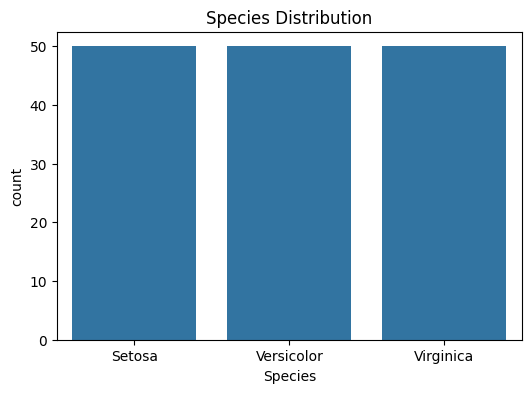

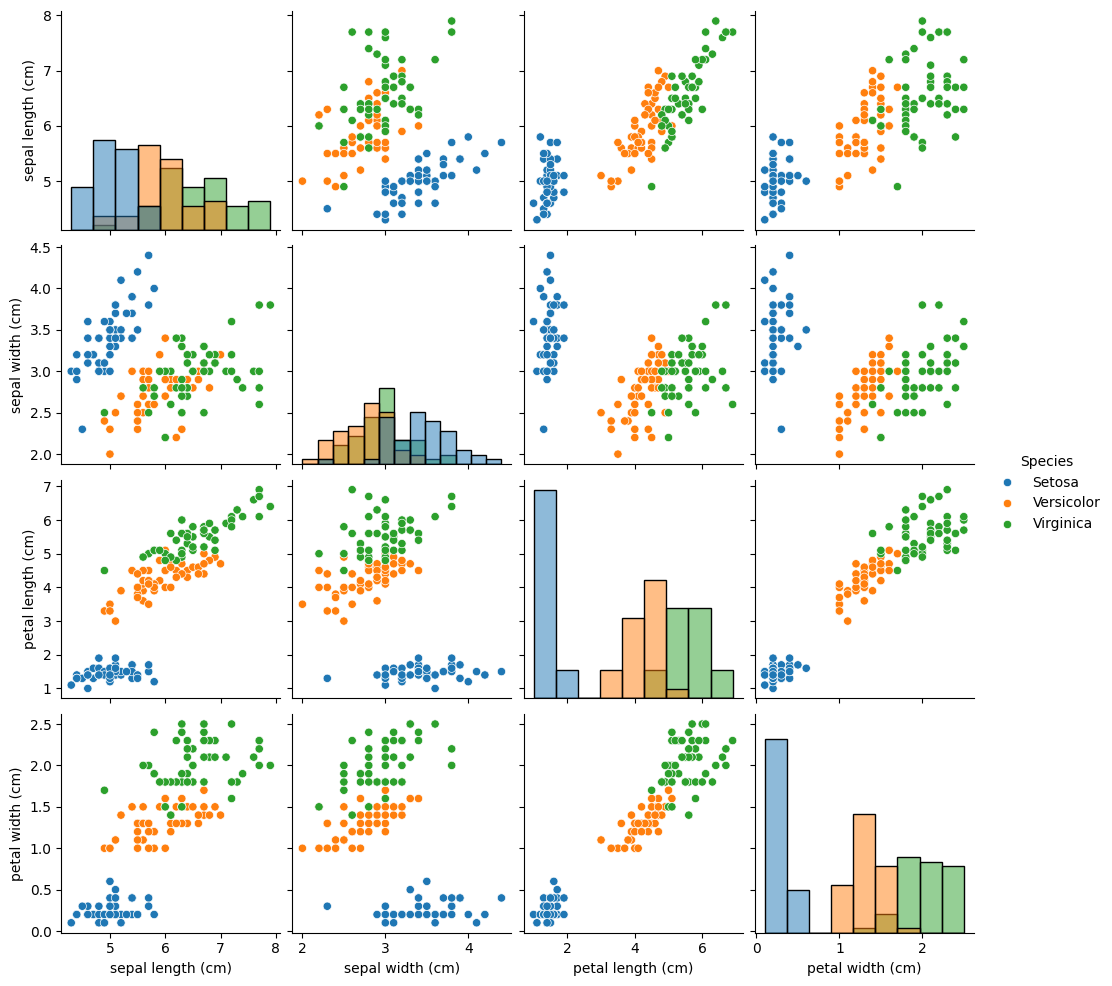

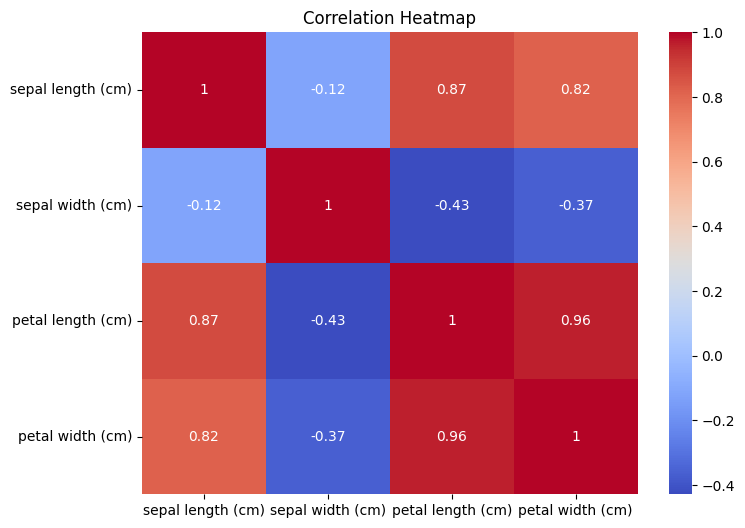

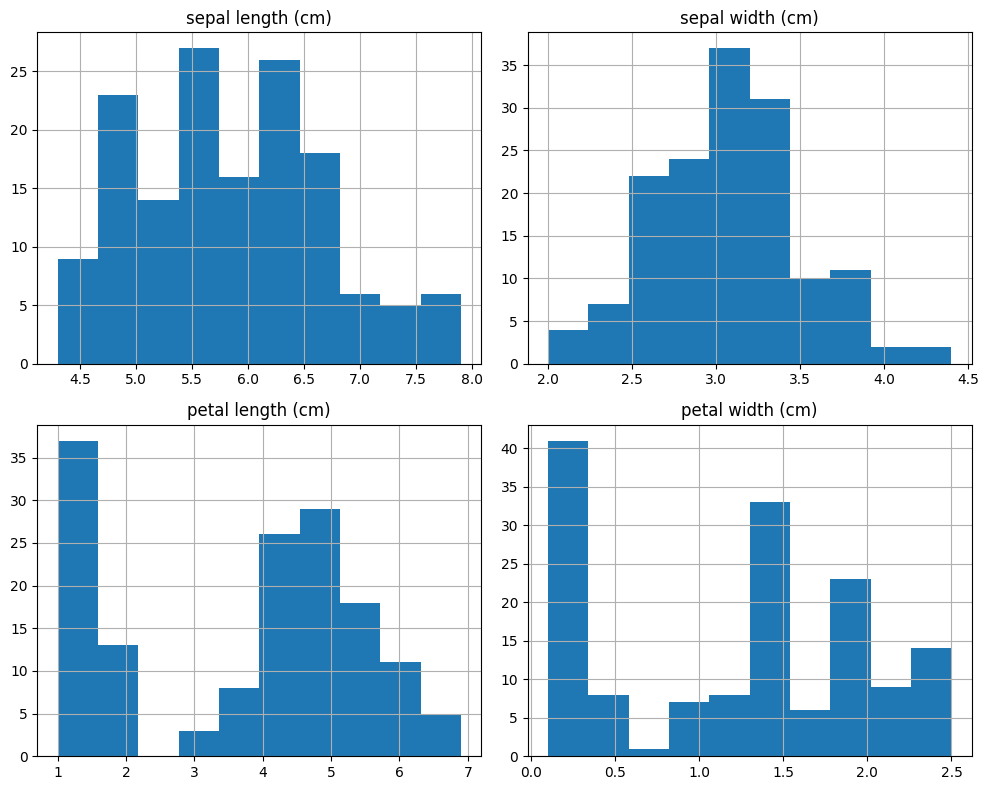

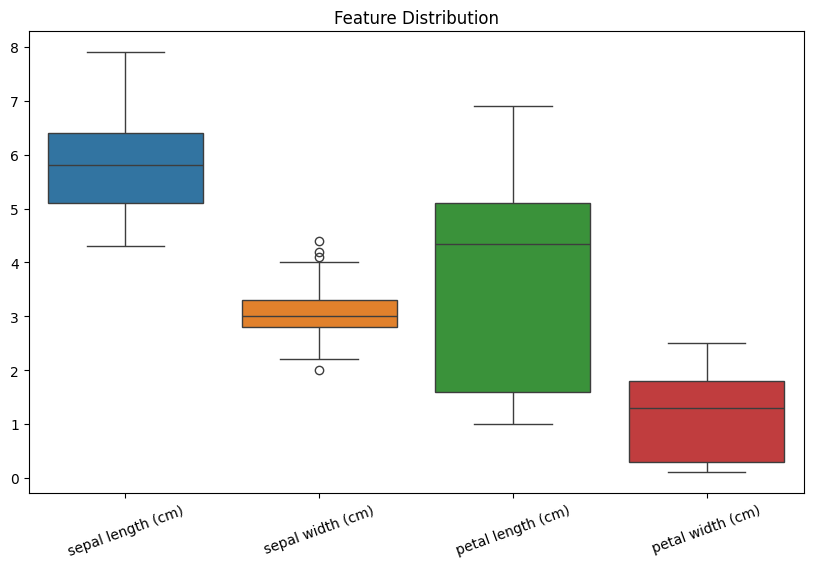

In [40]:
#plots
plt.figure(figsize=(6,4))

sns.countplot(
    data=iris_df,
    x="Species"
)

plt.title("Species Distribution")
plt.show()


sns.pairplot(
    iris_df,
    hue="Species",
    diag_kind="hist"
)

plt.show()


plt.figure(figsize=(8,6))

sns.heatmap(
    iris_df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

iris_df.hist(figsize=(10,8))

plt.tight_layout()

plt.show()


plt.figure(figsize=(10,6))

sns.boxplot(data=iris_df.drop("Species", axis=1))

plt.xticks(rotation=20)

plt.title("Feature Distribution")

plt.show()

In [3]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
iris = load_iris()
x= pd.DataFrame(
    iris.data, columns = iris.feature_names)
y= iris.target
print(x.head())
print(y[:5])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
[0 0 0 0 0]


In [6]:
# train ,validation , test-split
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

iris = load_iris()

x = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42,stratify=y_test)
print(x_train.shape,x_val.shape,x_test.shape)
print(y_train.shape,y_val.shape,y_test.shape)

(105, 4) (22, 4) (23, 4)
(105,) (22,) (23,)


In [7]:
#STANDARDISATION
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [15]:
#models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


In [18]:
# 5 fold cross validation
results = []
for name , model in models.items():
  scores = cross_val_score(
      model ,
      x_train,
      y_train,
      cv=5,
      scoring='accuracy'
  )
  results.append(
      [
          name,
          np.mean(scores),
          np.std(scores)
      ]
  )
  cv_df = pd.DataFrame(results, columns=['model', 'mean_accuracy', 'std_accuracy'])
  print(cv_df)


                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.980952      0.023328
                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.980952      0.023328
1                  KNN       0.952381      0.042592
                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.980952      0.023328
1                  KNN       0.952381      0.042592
2                  SVM       0.971429      0.023328
                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.980952      0.023328
1                  KNN       0.952381      0.042592
2                  SVM       0.971429      0.023328
3        Decision Tree       0.942857      0.019048
                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.980952      0.023328
1                  KNN       0.952381      0.042592
2                  SVM       0.971429      0.023328
3        Decision Tree       0.942857      0.019048
4        Ran

In [19]:
print(type(models))
print(models)

<class 'dict'>
{'Logistic Regression': LogisticRegression(max_iter=1000), 'KNN': KNeighborsClassifier(), 'SVM': SVC(), 'Decision Tree': DecisionTreeClassifier(random_state=42), 'Random Forest': RandomForestClassifier(random_state=42)}


In [22]:
#hyperparameter tuning
#logistic regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2"]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        solver='liblinear'
    ),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 100, 'penalty': 'l1'}
Best CV Accuracy: 0.980952380952381


In [25]:
#final training
best_model = grid_search.best_estimator_
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
Y= best_model.predict(x_test)
print(Y)

Test Accuracy: 0.9565217391304348
[0 0 1 1 2 2 1 2 0 1 1 0 1 2 1 2 0 1 2 0 1 2 0]


In [29]:
# EVALUATION METRICS
accuracy= accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average='weighted')
recall=recall_score(y_test,y_pred,average='weighted')
print(accuracy)
print(precision)
print(recall)
print(f1_score)

0.9565217391304348
0.9613526570048309
0.9565217391304348
0.9563512361466325


Confusion Matrix:
[[7 0 0]
 [0 8 0]
 [0 1 7]]


Text(0.5, 1.0, 'Confusion Matrix')

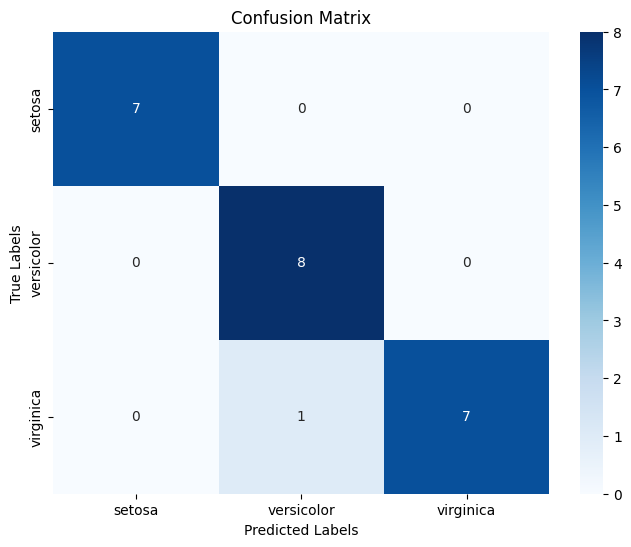

In [31]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

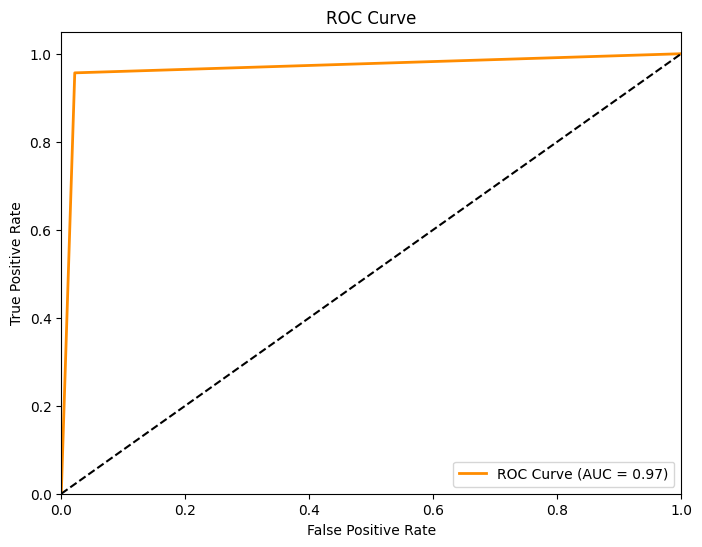

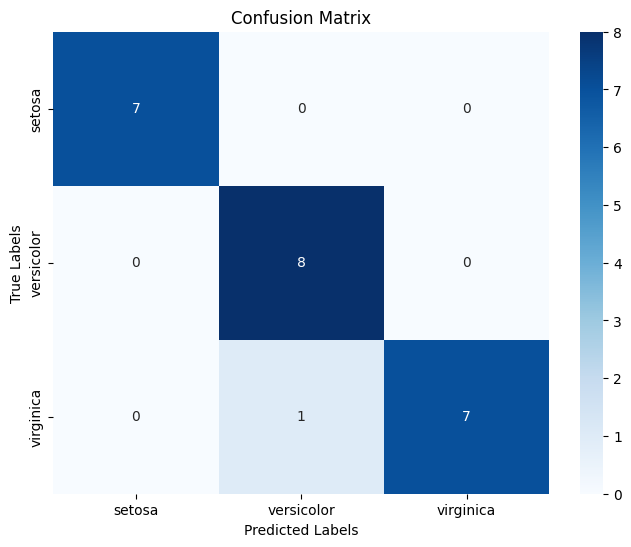

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = best_model.predict(x_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_bin = label_binarize(y_pred, classes=[0,1,2])

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [36]:
comparison = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)

    comparison.append([name, accuracy])   # <-- append() called correctly

comparison_df = pd.DataFrame(comparison, columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
comparison_df = comparison_df.set_index('Model')
comparison_df['Accuracy'] = comparison_df['Accuracy'].round(4)

print(comparison_df)


                     Accuracy
Model                        
SVM                    1.0000
Logistic Regression    0.9565
KNN                    0.9130
Decision Tree          0.9130
Random Forest          0.9130
